# Chapter 6: Soft Actor-Critic (SAC)
### **RL: The Seminal Papers** by Rahul Shirale

Interactive companion notebook for Chapter 6. We implement **Soft Actor-Critic** from Haarnoja et al. (2018) — both the original *Off-Policy Maximum Entropy* paper and the **SAC-v2** algorithm with automatic temperature tuning. SAC pairs an off-policy replay buffer with a **maximum entropy objective** that makes exploration a first-class part of the reward, reaching a competent `Pendulum-v1` policy in a few minutes on a standard CPU.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rshirale/rl-seminal-papers/blob/main/src/part_2_methods/ch06_sac/Chapter6_SAC.ipynb)

## 1. Setup
The cell below installs dependencies. In Google Colab, uncomment and run it. Locally, use `make install-full` from the repo root. Pin `numpy<2` so it stays compatible with the installed PyTorch build.

In [1]:
# In Google Colab, uncomment to install dependencies:
# !pip install "torch>=2.0.0" "gymnasium[classic-control]>=0.28.1" matplotlib "numpy<2"

import copy
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch: {torch.__version__} | Gymnasium: {gym.__version__} | NumPy: {np.__version__}")

PyTorch: 2.2.2 | Gymnasium: 1.1.1 | NumPy: 1.26.4


## 2. The maximum entropy objective

Standard RL maximizes expected return. SAC augments every step with a policy-entropy bonus weighted by a temperature *alpha*:

$$J(\pi) = \sum_t \mathbb{E}\left[\, r(s_t, a_t) + \alpha\, \mathcal{H}(\pi(\cdot \mid s_t)) \,\right]$$

The entropy term rewards the agent for acting as randomly as possible while still collecting reward — yielding wider exploration, multiple viable behaviors, and faster learning on hard tasks. As *alpha* approaches 0 the objective collapses back to standard RL.

## 3. The stochastic squashed-Gaussian actor

SAC's actor **must** be stochastic: the entropy of a deterministic (Dirac-delta) policy is negative infinity, so the entropy bonus is undefined. The actor outputs a Gaussian over an unbounded variable *u*, samples it with the **reparameterization trick** (so gradients flow through the sample), then squashes with `tanh` to respect the action bounds.

The log-probability needs a change-of-variables correction for `tanh` (plus the action-scale term) — omitting it is the single most common SAC bug, biasing the entropy estimate that drives training.

In [2]:
import torch
import torch.nn as nn
from torch.distributions import Normal

LOG_STD_MIN = -5.0
LOG_STD_MAX = 2.0


class Actor(nn.Module):
    """
    Stochastic squashed-Gaussian policy from Haarnoja et al. (2018),
    "Soft Actor-Critic ..." (Appendix C).

    A shared two-layer backbone feeds separate mean and log-std heads. The
    mathematical requirement behind a *stochastic* actor is the maximum
    entropy objective: a deterministic policy is a Dirac delta with
    negative-infinite entropy, so SAC cannot use one.

    Actions are drawn with the reparameterization trick, squashed with tanh
    to respect the action bounds, and scaled by max_action. The returned
    log-probability includes the tanh change-of-variables correction *and*
    the action-scale term, so the entropy estimate that drives training is
    unbiased (as in Stable-Baselines3 and CleanRL).
    """

    def __init__(self, state_dim: int, action_dim: int,
                 max_action: float = 1.0, hidden: int = 256):
        super().__init__()
        self.max_action = max_action
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden, action_dim)
        self.log_std_head = nn.Linear(hidden, action_dim)

    def forward(self, state: torch.Tensor, deterministic: bool = False):
        """
        Return (action, log_prob).

        With deterministic=True the mean action (tanh(μ)·max_action) is
        returned for evaluation and log_prob is None — the paper notes the
        mean action typically yields slightly higher returns at eval time.
        Otherwise an action is sampled via the reparameterization trick and
        its corrected log-probability is returned.
        """
        x = self.net(state)
        mean = self.mean_head(x)
        log_std = self.log_std_head(x).clamp(LOG_STD_MIN, LOG_STD_MAX)
        std = log_std.exp()

        if deterministic:
            return torch.tanh(mean) * self.max_action, None

        dist = Normal(mean, std)
        u = dist.rsample()                 # reparameterized: u = μ + σ·ε
        y = torch.tanh(u)                  # squash to (-1, 1)
        action = y * self.max_action

        # log π(a|s) = log μ(u|s) − Σ log(max_action·(1 − tanh²(u)))
        log_prob = dist.log_prob(u)
        log_prob -= torch.log(self.max_action * (1 - y.pow(2)) + 1e-6)
        log_prob = log_prob.sum(-1, keepdim=True)
        return action, log_prob

## 4. Twin critics

A single critic tends to **overestimate** Q-values; the actor then chases those inflated estimates and training destabilizes. SAC trains two independent Q-networks and uses `min(Q1, Q2)` for the Bellman target — the clipped double-Q trick of Fujimoto et al. (2018).

In [3]:
import torch
import torch.nn as nn


class Critic(nn.Module):
    """
    Twin soft Q-networks from Haarnoja et al. (2018), "Soft Actor-Critic."

    Two independently initialized Q-networks Q1 and Q2 map (state, action)
    pairs to scalar soft Q-values. SAC uses the minimum of the two as the
    Bellman target — the clipped double-Q trick of Fujimoto et al. (2018) —
    to counteract the Q-value overestimation that would otherwise let the
    actor exploit inflated estimates.

    forward() returns both Q-values so the caller can apply min(Q1, Q2)
    without crossing the class boundary twice.
    """

    def __init__(self, state_dim: int, action_dim: int, hidden: int = 256):
        super().__init__()

        def mlp():
            return nn.Sequential(
                nn.Linear(state_dim + action_dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, 1),
            )

        self.q1 = mlp()
        self.q2 = mlp()

    def forward(self, state: torch.Tensor, action: torch.Tensor):
        sa = torch.cat([state, action], dim=-1)
        return self.q1(sa), self.q2(sa)

## 5. Replay buffer

Because the soft Bellman backup is off-policy, every past transition is valid training data. A fixed-capacity deque sampled uniformly at random is all we need.

In [4]:
import random
from collections import deque

import numpy as np
import torch


class ReplayBuffer:
    """
    Uniform experience replay storing (s, a, r, s', done) transitions.

    Identical in spirit to the DDPG buffer (chapter 4): a fixed-capacity
    deque sampled uniformly at random. Because SAC's soft Bellman backup is
    off-policy, every stored transition is valid training data regardless of
    which policy collected it. Default capacity of 1,000,000 matches SAC-v2.
    """

    def __init__(self, max_size: int = 1_000_000):
        self.buf = deque(maxlen=max_size)

    def push(self, s, a, r, ns, done):
        self.buf.append((s, a, r, ns, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s, a, r, ns, d = zip(*batch)
        to_t = lambda x: torch.FloatTensor(np.array(x))
        return (
            to_t(s), to_t(a),
            to_t(r).unsqueeze(1),
            to_t(ns),
            to_t(d).unsqueeze(1),
        )

    def __len__(self) -> int:
        return len(self.buf)

## 6. The SAC agent (automatic temperature)

The agent ties the pieces together and runs three gradient updates per call — critic, actor, and **temperature** — followed by a soft target-critic sync. The temperature *alpha* is learned by treating it as the Lagrange multiplier of an entropy constraint with target `H = -dim(A)`: if the policy's entropy drops below target, *alpha* rises; if it sits above, *alpha* falls. This removes per-environment reward-scale tuning.

In [5]:
import copy

import numpy as np
import torch
import torch.nn.functional as F



class SACAgent:
    """
    Soft Actor-Critic (SAC-v2) agent from Haarnoja et al. (2018),
    "Soft Actor-Critic Algorithms and Applications."

    Implements Algorithm 1:
      - Stochastic squashed-Gaussian actor  π_φ(a | s)
      - Twin soft critics  Q_θ1, Q_θ2  with min-clipped Bellman targets
      - Target critics updated by soft EMA (τ = 0.005); no target actor,
        since the stochastic policy already provides principled exploration
      - Automatic temperature tuning: α is the Lagrange multiplier of an
        entropy constraint, learned in log-space toward target_entropy
      - One gradient update per environment step (off-policy replay)
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        max_action: float,
        gamma: float = 0.99,
        tau: float = 0.005,
        actor_lr: float = 3e-4,
        critic_lr: float = 3e-4,
        alpha_lr: float = 3e-4,
        batch_size: int = 256,
        buffer_size: int = 1_000_000,
        target_entropy: float = None,
    ):
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.max_action = max_action
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.actor = Actor(state_dim, action_dim, max_action).to(self.device)
        self.critic = Critic(state_dim, action_dim).to(self.device)
        self.critic_target = copy.deepcopy(self.critic)
        for p in self.critic_target.parameters():
            p.requires_grad = False

        self.actor_opt = torch.optim.Adam(
            self.actor.parameters(), lr=actor_lr
        )
        self.critic_opt = torch.optim.Adam(
            self.critic.parameters(), lr=critic_lr
        )

        # Automatic temperature: optimize log α so that α = exp(log α) > 0.
        # The default target entropy H̄ = −dim(A) is the SAC-v2 heuristic.
        if target_entropy is None:
            target_entropy = -float(action_dim)
        self.target_entropy = target_entropy
        self.log_alpha = torch.zeros(
            1, requires_grad=True, device=self.device
        )
        self.alpha_opt = torch.optim.Adam([self.log_alpha], lr=alpha_lr)

        self.replay = ReplayBuffer(buffer_size)

    @property
    def alpha(self) -> float:
        return self.log_alpha.exp().item()

    def select_action(self, state: np.ndarray,
                      deterministic: bool = False) -> np.ndarray:
        """Sample an action; use the mean action when deterministic=True."""
        s_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            action, _ = self.actor(s_t, deterministic=deterministic)
        return action.squeeze(0).cpu().numpy()

    def store(self, s, a, r, ns, done):
        self.replay.push(s, a, r, ns, done)

    def train(self):
        """
        Run one critic + actor + temperature update and a soft target sync.
        Returns (critic_loss, actor_loss, alpha), or (None, None, None) if
        the buffer does not yet hold a full mini-batch.
        """
        if len(self.replay) < self.batch_size:
            return None, None, None

        s, a, r, ns, d = [t.to(self.device)
                          for t in self.replay.sample(self.batch_size)]
        alpha = self.log_alpha.exp().detach()

        # --- Critic update: soft Bellman target with min-clipped twin Q ---
        with torch.no_grad():
            na, log_pi_next = self.actor(ns)
            q1_t, q2_t = self.critic_target(ns, na)
            soft_v = torch.min(q1_t, q2_t) - alpha * log_pi_next
            y = r + self.gamma * (1 - d) * soft_v

        q1, q2 = self.critic(s, a)
        critic_loss = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        # --- Actor update: maximize min-Q minus the entropy penalty ---
        a_new, log_pi = self.actor(s)
        q1_pi, q2_pi = self.critic(s, a_new)
        actor_loss = (alpha * log_pi - torch.min(q1_pi, q2_pi)).mean()
        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        # --- Temperature update: drive entropy toward the target ---
        alpha_loss = -(
            self.log_alpha * (log_pi + self.target_entropy).detach()
        ).mean()
        self.alpha_opt.zero_grad()
        alpha_loss.backward()
        self.alpha_opt.step()

        self._soft_update(self.critic_target, self.critic)

        return (
            critic_loss.item(),
            actor_loss.item(),
            self.log_alpha.exp().item(),
        )

    def _soft_update(self, target: torch.nn.Module,
                     source: torch.nn.Module):
        for tp, sp in zip(target.parameters(), source.parameters()):
            tp.data.copy_(self.tau * sp.data + (1 - self.tau) * tp.data)

## 7. Training on Pendulum-v1

The loop alternates one environment step with one gradient update. Random actions during a short warmup seed the replay buffer. We store the **termination** flag only — a time-limit truncation is not a true terminal state, so the target keeps bootstrapping (Pendulum-v1 only ever truncates).

The step counts below are reduced from the script's defaults (`train_pendulum.py` uses 10k warmup / 50k total) so the notebook finishes quickly.

In [6]:
env = gym.make("Pendulum-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])
env.action_space.seed(SEED)

agent = SACAgent(state_dim, action_dim, max_action)

WARMUP_STEPS = 5_000     # random actions before the first gradient update
TOTAL_STEPS  = 25_000    # train_pendulum.py uses 50_000

state, _ = env.reset(seed=SEED)
ep_return, episode = 0.0, 0
ep_returns, ep_alphas = [], []

for step in range(1, TOTAL_STEPS + 1):
    if len(agent.replay) < WARMUP_STEPS:
        action = env.action_space.sample()
    else:
        action = agent.select_action(state)

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    agent.store(state, action, reward, next_state, float(terminated))
    state = next_state
    ep_return += reward

    if len(agent.replay) >= WARMUP_STEPS:
        agent.train()

    if done:
        episode += 1
        ep_returns.append(ep_return)
        ep_alphas.append(agent.alpha)
        if episode % 10 == 0:
            avg = np.mean(ep_returns[-10:])
            print(f"Episode {episode:3d} | Step {step:5d} | "
                  f"Return {ep_return:8.1f} | Avg-10 {avg:8.1f} | "
                  f"alpha {agent.alpha:.3f}")
        state, _ = env.reset()
        ep_return = 0.0

env.close()
print()
print("Final 10-episode average:", round(float(np.mean(ep_returns[-10:])), 1))

Episode  10 | Step  2000 | Return  -1399.4 | Avg-10  -1223.7 | alpha 1.000
Episode  20 | Step  4000 | Return  -1381.3 | Avg-10  -1194.7 | alpha 1.000


Episode  30 | Step  6000 | Return  -1598.1 | Avg-10  -1223.9 | alpha 0.744


Episode  40 | Step  8000 | Return   -257.7 | Avg-10   -982.5 | alpha 0.443


Episode  50 | Step 10000 | Return   -246.0 | Avg-10   -186.0 | alpha 0.276


Episode  60 | Step 12000 | Return     -2.6 | Avg-10   -285.6 | alpha 0.173


...

Episode  90 | Step 18000 | Return   -226.5 | Avg-10   -118.2 | alpha 0.057


Episode 100 | Step 20000 | Return   -115.4 | Avg-10   -144.9 | alpha 0.037


Episode 110 | Step 22000 | Return   -236.7 | Avg-10   -175.9 | alpha 0.024


Episode 120 | Step 24000 | Return   -225.0 | Avg-10   -166.3 | alpha 0.020



Final 10-episode average: -154.9


## 8. Diagnostics: temperature and reward

Two signals confirm healthy training: *alpha* holds at 1.0 through the warmup and then decays as the policy sharpens, while the episode reward climbs out of the ~-1200 warmup band and settles toward roughly -150.

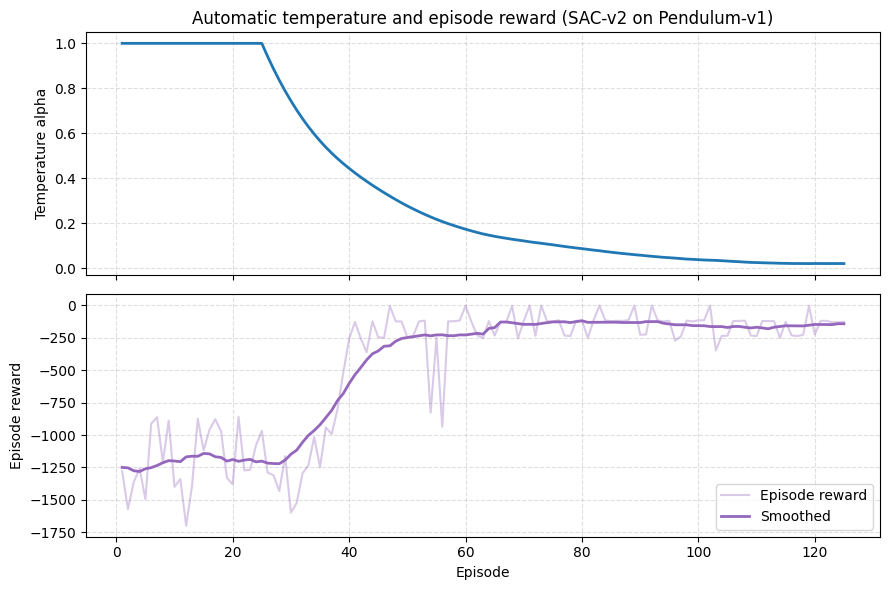

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
episodes = range(1, len(ep_returns) + 1)

ax1.plot(episodes, ep_alphas, color="#1f77b4", lw=2)
ax1.set_ylabel("Temperature alpha")
ax1.set_title("Automatic temperature and episode reward (SAC-v2 on Pendulum-v1)")
ax1.grid(True, ls="--", alpha=0.4)


def smooth(y, k=9):
    if len(y) <= 1:
        return np.array(y, dtype=float)
    arr = np.array(y, dtype=float)
    pad = np.pad(arr, (k, k), mode="edge")
    kernel = np.ones(2 * k + 1) / (2 * k + 1)
    return np.convolve(pad, kernel, mode="same")[k:-k]


ax2.plot(episodes, ep_returns, color="#9467bd", alpha=0.35, label="Episode reward")
ax2.plot(episodes, smooth(ep_returns), color="#9467bd", lw=2, label="Smoothed")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Episode reward")
ax2.grid(True, ls="--", alpha=0.4)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 9. Evaluating the trained policy

At evaluation time, use the actor's **mean** action rather than a stochastic sample. The policy was trained on the entropy-augmented objective, so the deterministic mean typically scores slightly higher on the pure-reward objective used for reporting.

In [8]:
eval_env = gym.make("Pendulum-v1")
eval_returns = []
for ep in range(5):
    s, _ = eval_env.reset(seed=1000 + ep)
    total, done = 0.0, False
    while not done:
        a = agent.select_action(s, deterministic=True)   # mean action
        s, r, term, trunc, _ = eval_env.step(a)
        total += r
        done = term or trunc
    eval_returns.append(total)
eval_env.close()

print("Deterministic eval returns:", [round(x, 1) for x in eval_returns])
print("Mean:", round(float(np.mean(eval_returns)), 1))

Deterministic eval returns: [-2.5, -131.3, -125.6, -116.4, -331.9]
Mean: -141.5


## 10. Using the module files

This notebook is self-contained for learning. The same code lives as importable modules in this directory, and a full training run is one command away.

In [9]:
# Import the modular versions (run locally from the ch06_sac directory):
#   from actor import Actor
#   from critic import Critic
#   from replay_buffer import ReplayBuffer
#   from sac_agent import SACAgent
#
# Run the full 50,000-step training from the repo root:
#   make run-ch6-pendulum
# or directly:
#   python src/part_2_methods/ch06_sac/train_pendulum.py